# Computational Economics with SciPy
## A Data Analytics Project — Market Equilibrium, Optimization, Growth & Cycles

*Based on Steinkamp, V., "Python for Engineering and Scientific Computing" (2024),
Chapter 6 — "Numerical Computations and Simulations Using SciPy".*

Every numerical technique in this notebook (root-finding, constrained optimization,
interpolation, differentiation, integration, ODEs, FFT) mirrors an example from the
source chapter, retargeted from engineering signals to economic data. Work through
the notebook top to bottom; each section has:

1. **Theory** (markdown) — the economic model and the math behind it.
2. **Data** — a synthetic, reproducible dataset (fixed random seed).
3. **Task** — `TODO` cells for you to complete.
4. **Interpretation** — a short markdown cell where you explain the result in words.

Run the setup cell first.

## 0. Setup

Import the libraries used throughout the project. If `numdifftools` is not
installed, run `!pip install numdifftools --break-system-packages` in a cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import root, minimize
from scipy.interpolate import interp1d, CubicSpline
from scipy.integrate import quad, solve_ivp
from scipy.fft import fft, fftfreq
import numdifftools as nd

np.random.seed(42)          # reproducibility -- keep this seed unchanged
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

## 1. Market Equilibrium via Root-Finding
### (mirrors book §6.1, `scipy.optimize.root`)

**Theory.** A market is in equilibrium at the price `p*` where quantity demanded
equals quantity supplied. We use a *constant-elasticity* demand and supply system,
which — like the damped-oscillation example in the book — has no clean algebraic
solution, so we solve it numerically:

- Demand: `Qd(p) = A * p**(-eps_d)`  (eps_d = price elasticity of demand, eps_d > 0)
- Supply: `Qs(p) = B * p**(eps_s)`   (eps_s = price elasticity of supply, eps_s > 0)

Equilibrium condition: `f(p) = Qd(p) - Qs(p) = 0`.

Just as Listing 6.1 calls `root(f, x0, method='hybr')` to find the zeros of a
damped sine wave, we call `root()` on the excess-demand function `f(p)`.

In [2]:
# ---- Synthetic market parameters (given) ----
A, eps_d = 500.0, 1.4     # demand scale and elasticity (elastic: eps_d > 1)
B, eps_s = 8.0, 1.2       # supply scale and elasticity

def demand(p):
    return A * p**(-eps_d)

def supply(p):
    return B * p**(eps_s)

Equilibrium price p* = 4.906
Equilibrium quantity q* = 53.946


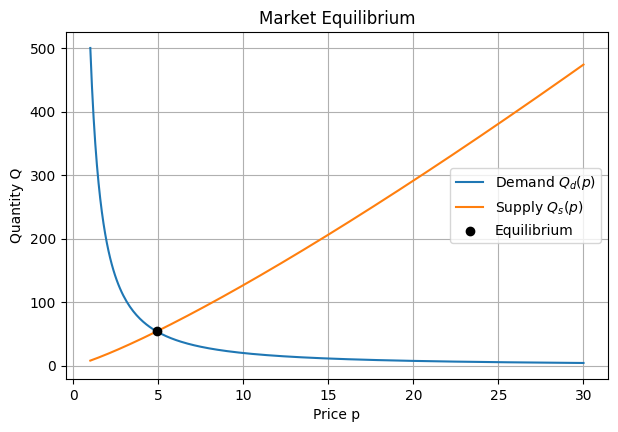

In [3]:
def excess_demand(p):
    return demand(p) - supply(p)

# Solve for the equilibrium price starting from a guess p0 = 10
p0 = [10.0]
sol = root(excess_demand, p0, method='hybr')
p_star = sol.x[0]
q_star = demand(p_star)

print(f"Equilibrium price p* = {p_star:.3f}")
print(f"Equilibrium quantity q* = {q_star:.3f}")

# ---- Plot supply & demand curves with equilibrium marked ----
p_grid = np.linspace(1, 30, 300)
fig, ax = plt.subplots()
ax.plot(p_grid, demand(p_grid), label="Demand $Q_d(p)$", color="tab:blue")
ax.plot(p_grid, supply(p_grid), label="Supply $Q_s(p)$", color="tab:orange")
ax.scatter([p_star], [q_star], color="k", zorder=5, label="Equilibrium")
ax.set(xlabel="Price p", ylabel="Quantity Q", title="Market Equilibrium")
ax.legend()
plt.show()

**Interpretation (answer here).** What happens to the equilibrium price and
quantity if demand becomes *more* elastic (increase `eps_d`)? Try it and briefly
explain the economic intuition in 2–3 sentences.

## 2. Cost-Minimizing Input Mix (Constrained Optimization)
### (mirrors book §6.2, `scipy.optimize.minimize` — the cylinder-surface-area problem)

**Theory.** A firm produces output with a Cobb–Douglas technology
`Q(K, L) = K**alpha * L**beta` where `K` = capital, `L` = labor. Capital costs
`r` per unit and labor costs `w` per unit. The firm wants to produce a target
output `Q0` at minimum cost:

```
minimize   C(K, L) = r*K + w*L
subject to Q(K, L) = Q0,   K > 0, L > 0
```

This is exactly the structure of the tin-can (cylinder) minimization in the book
(minimize surface area subject to a fixed volume) — here we minimize cost subject
to a fixed output. We use `scipy.optimize.minimize` with an equality constraint
(SLSQP method).

In [4]:
# ---- Given parameters ----
alpha, beta = 0.35, 0.65     # Cobb-Douglas exponents (decreasing/const/incr. returns -> alpha+beta)
r, w = 4.0, 2.5               # price of capital, price of labor
Q0 = 1000.0                   # required output level

Cost-minimizing capital K* = 492.69
Cost-minimizing labor    L* = 1463.99
Minimum cost C* = 5630.73
Check output = 1000.00 (target 1000.0)


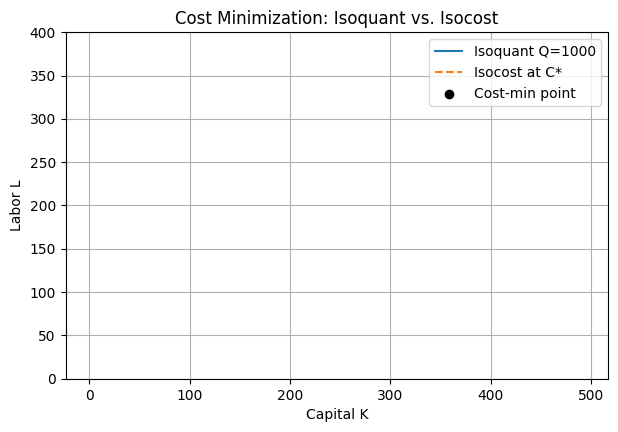

In [5]:
def cost(x):
    K, L = x
    return r*K + w*L

def output_constraint(x):
    K, L = x
    return K**alpha * L**beta - Q0   # must equal 0

x0 = [50.0, 50.0]  # initial guess (K0, L0)
constraints = [{"type": "eq", "fun": output_constraint}]
bounds = [(1e-6, None), (1e-6, None)]  # K, L > 0

result = minimize(cost, x0, method="SLSQP", bounds=bounds, constraints=constraints)
K_star, L_star = result.x
print(f"Cost-minimizing capital K* = {K_star:.2f}")
print(f"Cost-minimizing labor    L* = {L_star:.2f}")
print(f"Minimum cost C* = {result.fun:.2f}")
print(f"Check output = {K_star**alpha * L_star**beta:.2f} (target {Q0})")

# ---- Visualize: isoquant Q=Q0 and isocost line through the optimum ----
K_grid = np.linspace(1, 400, 400)
L_isoquant = (Q0 / K_grid**alpha) ** (1/beta)
L_isocost = (result.fun - r*K_grid) / w

fig, ax = plt.subplots()
ax.plot(K_grid, L_isoquant, label=f"Isoquant Q={Q0:.0f}")
ax.plot(K_grid, L_isocost, "--", label="Isocost at C*")
ax.scatter([K_star], [L_star], color="k", zorder=5, label="Cost-min point")
ax.set(xlabel="Capital K", ylabel="Labor L", ylim=(0, 400),
       title="Cost Minimization: Isoquant vs. Isocost")
ax.legend()
plt.show()

**Interpretation (answer here).** If the price of labor `w` doubles, would you
expect `K*` to rise or fall relative to `L*`? Re-run with `w = 5.0` and confirm.

## 3. Building a Yield Curve (Interpolation)
### (mirrors book §6.3, `scipy.interpolate.interp1d` — recovering a sampled signal)

**Theory.** Bond yields are only observed at a handful of standard maturities
(e.g., 3-month, 2-year, 10-year). To price a bond with a maturity that falls
*between* these points, or to compute the whole term structure, analysts
**interpolate**. Just as the book recovers a continuous signal from sampled
points, we recover a continuous yield curve from discrete market quotes.

We compare **linear interpolation** (`interp1d`, kind='linear') against a
**cubic spline** (`CubicSpline`), which is the standard choice for yield curves
because it is smooth (continuous first and second derivatives) — important
because the *slope* of the yield curve is itself economically meaningful
(term premium).

In [6]:
# ---- Observed market yields at standard maturities (synthetic but realistic) ----
maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])   # in years
yields_pct = np.array([4.85, 4.80, 4.55, 4.20, 4.05, 4.10, 4.25, 4.45, 4.70, 4.65])

df_yields = pd.DataFrame({"Maturity (yrs)": maturities, "Yield (%)": yields_pct})
df_yields

,Maturity (yrs),Yield (%)
0,0.25,4.85
1,0.50,4.80
2,1.00,4.55
3,2.00,4.20
4,3.00,4.05
5,5.00,4.10
6,7.00,4.25
7,10.00,4.45
8,20.00,4.70
9,30.00,4.65


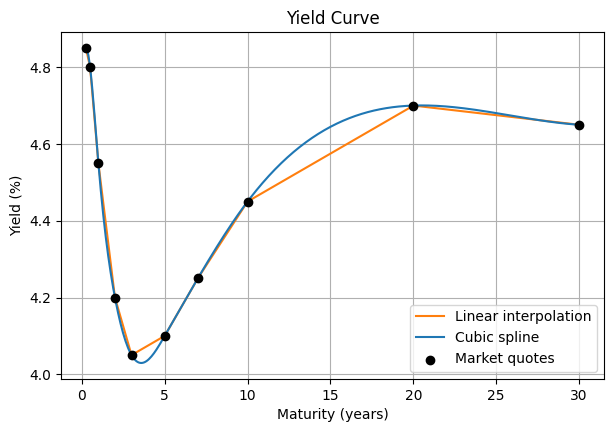

Linear estimate  of 4y yield: 4.075%
Cubic spline estimate of 4y yield: 4.038%
10y-2y term spread: 0.250 percentage points


In [7]:
lin_interp = interp1d(maturities, yields_pct, kind="linear")
cubic_interp = CubicSpline(maturities, yields_pct)

t_grid = np.linspace(maturities.min(), maturities.max(), 400)

fig, ax = plt.subplots()
ax.plot(t_grid, lin_interp(t_grid), label="Linear interpolation", color="tab:orange")
ax.plot(t_grid, cubic_interp(t_grid), label="Cubic spline", color="tab:blue")
ax.scatter(maturities, yields_pct, color="k", zorder=5, label="Market quotes")
ax.set(xlabel="Maturity (years)", ylabel="Yield (%)", title="Yield Curve")
ax.legend()
plt.show()

# Estimate the yield for an off-grid maturity, e.g. a 4-year bond
t_query = 4.0
print(f"Linear estimate  of 4y yield: {lin_interp(t_query):.3f}%")
print(f"Cubic spline estimate of 4y yield: {cubic_interp(t_query):.3f}%")

# Term spread (10y - 2y), a classic recession-predictor indicator
spread = cubic_interp(10) - cubic_interp(2)
print(f"10y-2y term spread: {spread:.3f} percentage points")

**Interpretation (answer here).** Where do linear and cubic-spline estimates
differ the most, and why does that make sense given how the two methods work?
What does a negative 10y-2y spread mean economically?

## 4. Marginal Analysis & Market Surplus (Differentiation & Integration)
### (mirrors book §6.4 `numdifftools.Derivative` and §6.5 `scipy.integrate.quad`)

**Theory — differentiation.** A firm's total cost function is
`TC(Q) = 50 + 0.02*Q**2 + 4*Q`. The **marginal cost** is `MC(Q) = d(TC)/dQ`.
Just as the book differentiates a position function to get velocity
(free-fall example), we differentiate total cost to get marginal cost, using
`numdifftools.Derivative` exactly as in Listing 6.10.

**Theory — integration.** At the market equilibrium from Section 1
(`p*`, `q*`), **consumer surplus** is the area between the demand curve and the
horizontal line at `p*`, and **producer surplus** is the area between `p*` and
the supply curve:

```
CS = ∫₀^{q*} [ P_d(q) - p* ] dq
PS = ∫₀^{q*} [ p* - P_s(q) ] dq
```

where `P_d(q)` and `P_s(q)` are the **inverse** demand/supply functions
(price as a function of quantity). We compute these with `scipy.integrate.quad`,
exactly as the book integrates to find displacement or work done.

*Technical note:* for the constant-elasticity demand curve from Section 1, the
consumer-surplus integral only **converges** to a finite value when demand is
elastic (`eps_d > 1`) — that's why Section 1 uses `eps_d = 1.4`. If you set
`eps_d < 1`, try re-running this cell and see what `quad` reports; it's a nice
illustration of how a model's math (not just its economics) can break down.

In [8]:
def TC(Q):
    return 50 + 0.02*Q**2 + 4*Q

# Inverse demand/supply (price as a function of quantity), consistent with
# Section 1's demand/supply if you like, but given directly here for clarity:
def P_demand(q):
    return (q / A) ** (-1/eps_d)     # inverse of demand(p) = A*p**-eps_d

def P_supply(q):
    return (q / B) ** (1/eps_s)      # inverse of supply(p) = B*p**eps_s

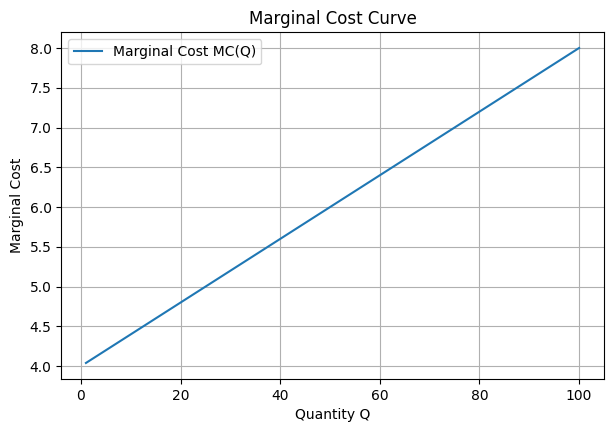

MC at Q=50: 6.000   (analytic check: 0.04*50+4 = 6.000)
Consumer surplus = 661.64
Producer surplus = 120.30
Total welfare (CS+PS) = 781.94


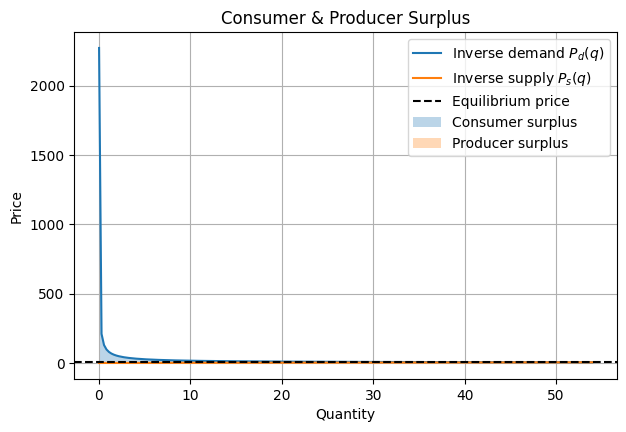

In [9]:
# ---- Marginal cost via numerical differentiation ----
MC = nd.Derivative(TC, n=1)

Q_grid = np.linspace(1, 100, 200)
mc_values = MC(Q_grid)

fig, ax = plt.subplots()
ax.plot(Q_grid, mc_values, label="Marginal Cost MC(Q)")
ax.set(xlabel="Quantity Q", ylabel="Marginal Cost", title="Marginal Cost Curve")
ax.legend()
plt.show()

print(f"MC at Q=50: {MC(50):.3f}   (analytic check: 0.04*50+4 = {0.04*50+4:.3f})")

# ---- Consumer & producer surplus at the Section-1 equilibrium (p_star, q_star) ----
CS, _ = quad(lambda q: P_demand(q) - p_star, 1e-8, q_star, limit=200)
PS, _ = quad(lambda q: p_star - P_supply(q), 1e-8, q_star, limit=200)

print(f"Consumer surplus = {CS:.2f}")
print(f"Producer surplus = {PS:.2f}")
print(f"Total welfare (CS+PS) = {CS+PS:.2f}")

# ---- Visualize the surplus areas ----
q_plot = np.linspace(0.01, q_star, 200)
fig, ax = plt.subplots()
ax.plot(q_plot, P_demand(q_plot), label="Inverse demand $P_d(q)$")
ax.plot(q_plot, P_supply(q_plot), label="Inverse supply $P_s(q)$")
ax.axhline(p_star, color="k", ls="--", label="Equilibrium price")
ax.fill_between(q_plot, P_demand(q_plot), p_star, alpha=0.3, label="Consumer surplus")
ax.fill_between(q_plot, p_star, P_supply(q_plot), alpha=0.3, label="Producer surplus")
ax.set(xlabel="Quantity", ylabel="Price", title="Consumer & Producer Surplus")
ax.legend()
plt.show()

**Interpretation (answer here).** Which is larger, consumer or producer
surplus, given the elasticities chosen in Section 1? Relate your answer to
the relative steepness (elasticity) of the two curves.

## 5. The Solow–Swan Growth Model (Differential Equations)
### (mirrors book §6.6, `scipy.integrate.solve_ivp` — spring-mass / population ODEs)

**Theory.** The Solow–Swan model describes how capital per worker `k(t)`
evolves over time:

```
dk/dt = s * k**alpha - (n + delta) * k
```

- `s`  = savings rate
- `alpha` = capital's share of output (Cobb-Douglas exponent)
- `n`  = population growth rate
- `delta` = capital depreciation rate

This is structurally identical to the second-order/first-order ODEs solved with
`solve_ivp` in the book (e.g., Listings 6.15–6.22) — here it's a first-order
nonlinear ODE with a stable fixed point (the steady state `k*`), the same kind
of long-run-equilibrium behavior as a damped oscillator settling to rest.

The steady state solves `s*k**alpha = (n+delta)*k`, giving
`k* = (s / (n+delta)) ** (1/(1-alpha))`.

In [10]:
s_rate, alpha_sw, n_rate, delta_rate = 0.25, 0.33, 0.015, 0.06
k0 = 1.0          # initial capital per worker
t_span = (0, 100) # years
t_eval = np.linspace(*t_span, 400)

Analytical steady state k* = 6.031
Simulated capital at t=100: 5.990


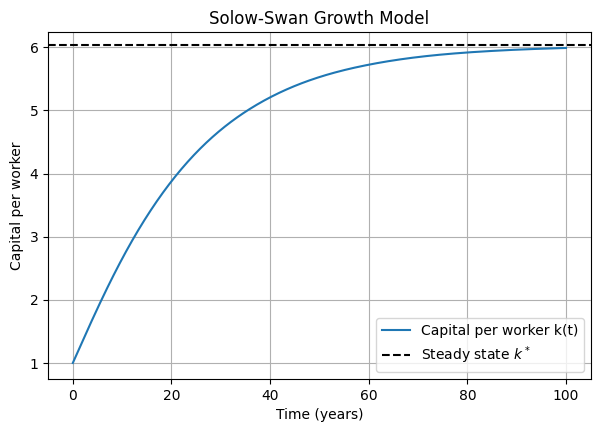

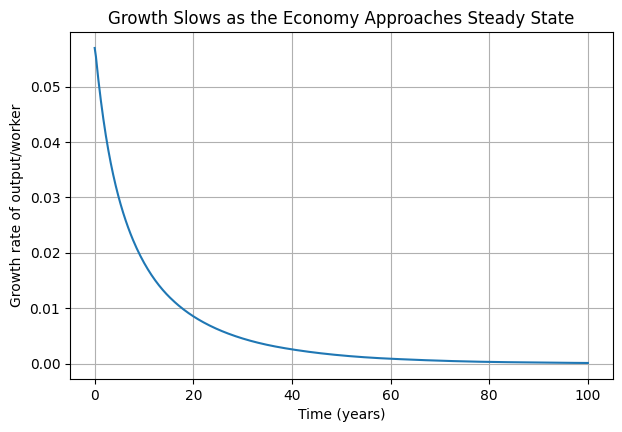

In [11]:
def solow(t, k):
    return s_rate * k[0]**alpha_sw - (n_rate + delta_rate) * k[0]

sol = solve_ivp(solow, t_span, [k0], t_eval=t_eval)

k_star = (s_rate / (n_rate + delta_rate)) ** (1/(1 - alpha_sw))
print(f"Analytical steady state k* = {k_star:.3f}")
print(f"Simulated capital at t=100: {sol.y[0, -1]:.3f}")

fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[0], label="Capital per worker k(t)")
ax.axhline(k_star, color="k", ls="--", label="Steady state $k^*$")
ax.set(xlabel="Time (years)", ylabel="Capital per worker",
       title="Solow-Swan Growth Model")
ax.legend()
plt.show()

# Output per worker y(t) = k(t)**alpha, and its growth rate
y_t = sol.y[0]**alpha_sw
growth_rate = np.gradient(y_t, sol.t) / y_t
fig, ax = plt.subplots()
ax.plot(sol.t, growth_rate)
ax.set(xlabel="Time (years)", ylabel="Growth rate of output/worker",
       title="Growth Slows as the Economy Approaches Steady State")
plt.show()

**Interpretation (answer here).** Increase the savings rate `s_rate` to 0.35
and re-run. Does the steady state `k*` rise or fall, and does the economy
temporarily grow faster or slower while transitioning to the new steady state?
This is the "Solow prediction" about savings-driven growth — summarize it in
2–3 sentences.

## 6. Detecting the Business Cycle (Fourier Transform)
### (mirrors book §6.7 and the bearing-vibration example in §6.9 —
### `scipy.fft.fft`/`fftfreq` used to find a hidden periodicity in a noisy signal)

**Theory.** Real GDP growth is noisy quarter to quarter, but many economies
exhibit a recurring **business cycle** (expansion/recession) with a period of
roughly 6–10 years. In the book, the exact same FFT technique is used to find
a hidden mechanical fault frequency buried in noisy vibration data (Listing
6.32, "Simulation of a Bearing Damage"). We apply it here to a synthetic GDP
growth series: trend + business-cycle oscillation + quarter-to-quarter noise.

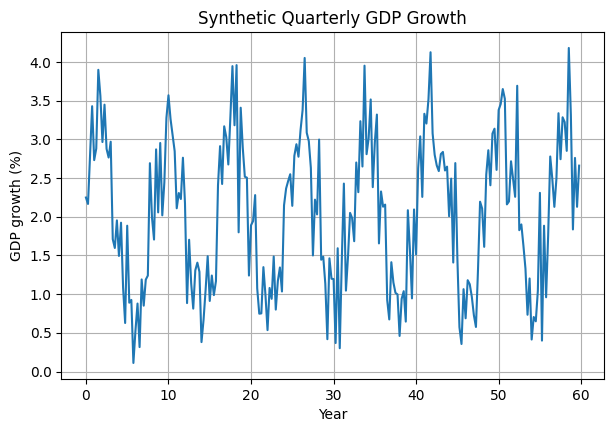

In [12]:
# ---- Synthetic quarterly GDP growth (%) over 60 years = 240 quarters ----
n_quarters = 240
t_q = np.arange(n_quarters)                  # quarter index
Ta = 0.25                                    # sampling interval in years (quarterly)

cycle_period_years = 8.0                     # the "true" business-cycle length we hid in the data
trend = 2.0                                  # average growth rate (%)
cycle_amplitude = 1.2
noise = np.random.normal(0, 0.5, n_quarters)

gdp_growth = (trend
              + cycle_amplitude * np.sin(2*np.pi * t_q * Ta / cycle_period_years)
              + noise)

fig, ax = plt.subplots()
ax.plot(t_q * Ta, gdp_growth)
ax.set(xlabel="Year", ylabel="GDP growth (%)", title="Synthetic Quarterly GDP Growth")
plt.show()

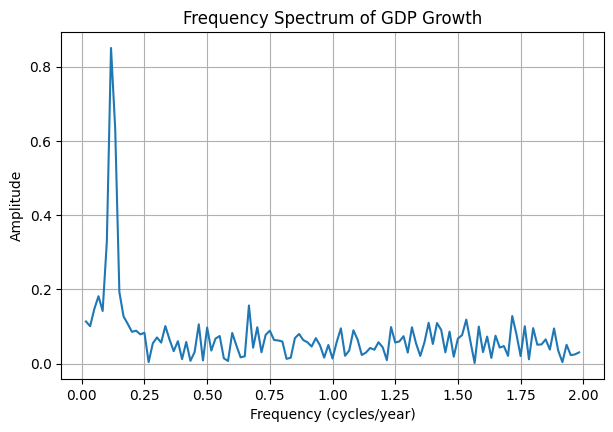

Dominant cycle frequency: 0.1167 cycles/year
Detected business-cycle length: 8.57 years
(True hidden cycle length was 8.0 years)


In [13]:
N = n_quarters
gdp_detrended = gdp_growth - gdp_growth.mean()   # remove the DC/trend component first

G_fft = fft(gdp_detrended)
freqs = fftfreq(N, Ta)          # cycles per year
amps = 2*np.abs(G_fft) / N

# keep only positive frequencies
pos = freqs > 0
fig, ax = plt.subplots()
ax.plot(freqs[pos], amps[pos])
ax.set(xlabel="Frequency (cycles/year)", ylabel="Amplitude",
       title="Frequency Spectrum of GDP Growth")
plt.show()

# Find the dominant frequency (largest amplitude, excluding f=0)
dominant_idx = np.argmax(amps[pos])
dominant_freq = freqs[pos][dominant_idx]
detected_period = 1 / dominant_freq
print(f"Dominant cycle frequency: {dominant_freq:.4f} cycles/year")
print(f"Detected business-cycle length: {detected_period:.2f} years")
print(f"(True hidden cycle length was {cycle_period_years} years)")

**Interpretation (answer here).** Increase the noise standard deviation
(e.g., to 1.5) and re-run. Is the FFT still able to recover the correct
cycle length? What does this tell you about using frequency-domain methods
on noisy macroeconomic data in practice?

## 7. Bonus: Technology Adoption — the Bass Diffusion Model
### (structurally the same ODE as the book's epidemic/SIR simulation, §6.11.5,
### Listing 6.34 — "Simulation of an Epidemic")

**Theory.** The Bass model describes how a new product or technology spreads
through a population of potential adopters — mathematically the same
"S-shaped diffusion" structure as an epidemic infecting a population:

```
dF/dt = (p + q*F) * (1 - F)
```

- `F(t)` = cumulative fraction of the population that has adopted by time `t`
- `p` = coefficient of innovation (adoption from advertising/external influence)
- `q` = coefficient of imitation (adoption from word-of-mouth/social influence,
  the same "contagion" mechanism as an epidemic's infection term)

We solve this with `solve_ivp`, exactly as the book solves the epidemic
`dgl(t, ya)` system, and plot the adoption curve and the "adoption rate"
(the new-adopters-per-period curve, which is the classic bell-shaped Bass curve).

In [14]:
p_innov, q_imit = 0.03, 0.38     # typical consumer-durable estimates
F0 = 0.001                        # tiny initial fraction of early adopters
t_span_bass = (0, 20)             # years
t_eval_bass = np.linspace(*t_span_bass, 400)

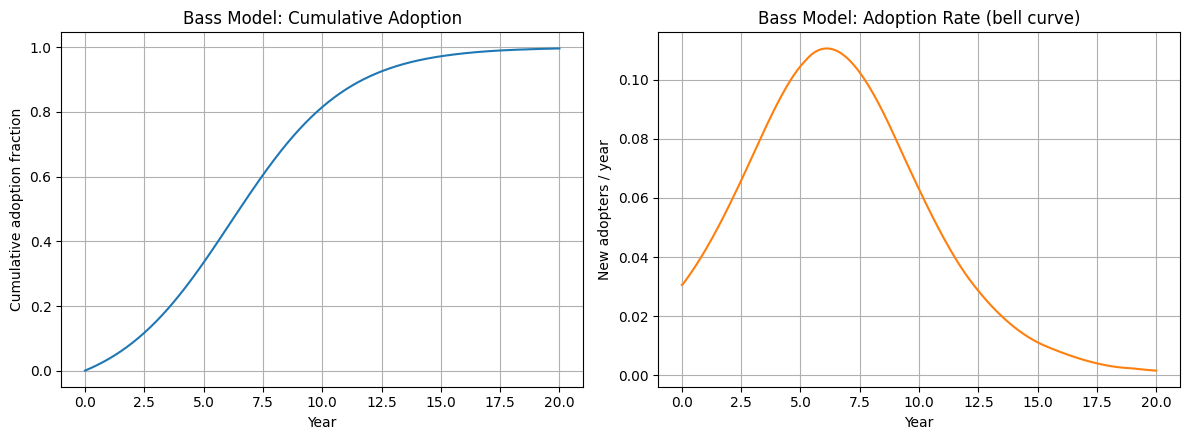

Peak adoption rate occurs at year 6.12


In [15]:
def bass(t, F):
    return (p_innov + q_imit*F[0]) * (1 - F[0])

sol_bass = solve_ivp(bass, t_span_bass, [F0], t_eval=t_eval_bass)
F_t = sol_bass.y[0]
adoption_rate = np.gradient(F_t, sol_bass.t)   # dF/dt, i.e. new adopters per year

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(sol_bass.t, F_t)
axes[0].set(xlabel="Year", ylabel="Cumulative adoption fraction",
            title="Bass Model: Cumulative Adoption")

axes[1].plot(sol_bass.t, adoption_rate, color="tab:orange")
axes[1].set(xlabel="Year", ylabel="New adopters / year",
            title="Bass Model: Adoption Rate (bell curve)")
plt.tight_layout()
plt.show()

t_peak = sol_bass.t[np.argmax(adoption_rate)]
print(f"Peak adoption rate occurs at year {t_peak:.2f}")

**Interpretation (answer here).** Increase `q_imit` (word-of-mouth strength)
and re-run. What happens to the timing and height of the adoption peak? Which
real-world products would you expect to have high `q` vs. high `p`?

## 8. Wrap-Up

Write a short (150–250 word) summary in this cell covering:

- One insight from the market-equilibrium/optimization sections (micro).
- One insight from the growth/business-cycle sections (macro).
- Which SciPy technique from the book's Chapter 6 you found most directly
  transferable to economic data analytics, and why.

*(Your answer here.)*